# 05 — Image Classification: FL vs NFL from Breath Waveform Images

Trains and evaluates three CNN models on the standardised breath image dataset produced by notebook 04.

## Models
| # | Model | Params | Notes |
|---|-------|--------|-------|
| 1 | **SimpleCNN** | ~200K | Trained from scratch; lightweight baseline |
| 2 | **ResNet18** | 11M | ImageNet pretrained; last layer replaced; all layers fine-tuned |
| 3 | **EfficientNet-B0** | 5.3M | ImageNet pretrained; last layer replaced; all layers fine-tuned |

## Evaluation design
- **Patient-level split** (70/15/15 train/val/test by patient, not by breath) to prevent breath-level leakage between the same patient across splits — mirrors the spirit of the LOPO-CV used in notebook 02
- Patients stratified by FL burden quartile before splitting so FL prevalence is balanced across splits
- **Metrics**: Accuracy, F1, ROC-AUC, Cohen's Kappa — same as notebook 02 for direct comparison
- **No data augmentation** beyond normalisation: horizontal/vertical flips would reverse the temporal or amplitude axis, which has physical meaning in flow waveforms

## Note on LOPO-CV
Full LOPO-CV (84 folds) is impractical for deep learning models. A single train/val/test patient split is used here. Results should be interpreted with that in mind when comparing to notebook 02 LOPO metrics.

## 1. Setup & Imports

In [1]:
import warnings
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights, EfficientNet_B0_Weights
from PIL import Image

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    cohen_kappa_score, confusion_matrix, roc_curve, auc,
    classification_report,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Configuration ─────────────────────────────────────────────────────────────
IMG_ROOT   = Path('./breath_images')   # output of notebook 04
OUT_DIR    = Path('./models')
OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 32
MAX_EPOCHS = 40
PATIENCE   = 7        # early stopping patience (epochs without val improvement)
LR         = 1e-4
SEED       = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    torch.device('cuda')  if torch.cuda.is_available()
    else torch.device('mps')   if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device     : {DEVICE}')
print(f'Image root : {IMG_ROOT.resolve()}')

# Verify images exist
fl_imgs  = list((IMG_ROOT / 'FL').glob('*.png'))
nfl_imgs = list((IMG_ROOT / 'NFL').glob('*.png'))
print(f'FL images  : {len(fl_imgs)}')
print(f'NFL images : {len(nfl_imgs)}')
assert len(fl_imgs) > 0 and len(nfl_imgs) > 0, 'No images found — run notebook 04 first'

Device     : mps
Image root : /Users/ashren/Desktop/uni/vandy/xai/project/breath_images
FL images  : 3638
NFL images : 3369


## 2. Patient-level Train / Val / Test Split

Images are named `{participant}_breath_{N}.png` so participant IDs are recoverable from filenames.
Patients are stratified by FL burden quartile before splitting so every split has a similar FL% distribution.

In [2]:
def participant_from_path(p: Path) -> str:
    """Extract participant ID from image filename: {pid}_breath_{n}.png"""
    # The participant ID is everything before '_breath_'
    return p.stem.rsplit('_breath_', 1)[0]


# ── Build per-image records ────────────────────────────────────────────────────
records = []
for label, label_dir, target in [('FL', IMG_ROOT / 'FL', 1),
                                   ('NFL', IMG_ROOT / 'NFL', 0)]:
    for p in label_dir.glob('*.png'):
        records.append({
            'path'        : p,
            'label'       : label,
            'target'      : target,
            'participant' : participant_from_path(p),
        })

img_df = pd.DataFrame(records)
print(f'Total images : {len(img_df)}')
print(f'Participants : {img_df["participant"].nunique()}')

# ── Per-patient FL burden ──────────────────────────────────────────────────────
pt_stats = (
    img_df.groupby('participant')
    .agg(n_total=('target', 'count'), n_fl=('target', 'sum'))
    .assign(fl_pct=lambda d: d['n_fl'] / d['n_total'])
    .reset_index()
)

# Stratify: sort by fl_pct, assign quartile, then split within each quartile
pt_stats = pt_stats.sort_values('fl_pct').reset_index(drop=True)
pt_stats['quartile'] = pd.qcut(pt_stats['fl_pct'], q=4, labels=False, duplicates='drop')

train_pids, val_pids, test_pids = [], [], []
rng = np.random.default_rng(SEED)

for _, grp in pt_stats.groupby('quartile'):
    pids = grp['participant'].tolist()
    rng.shuffle(pids)
    n = len(pids)
    n_val  = max(1, round(0.15 * n))
    n_test = max(1, round(0.15 * n))
    test_pids  += pids[:n_test]
    val_pids   += pids[n_test:n_test + n_val]
    train_pids += pids[n_test + n_val:]

train_df = img_df[img_df['participant'].isin(train_pids)].reset_index(drop=True)
val_df   = img_df[img_df['participant'].isin(val_pids)].reset_index(drop=True)
test_df  = img_df[img_df['participant'].isin(test_pids)].reset_index(drop=True)

print(f'\nSplit summary (by patient):')
print(f'  Train: {train_df["participant"].nunique()} patients, {len(train_df)} images '
      f'({100*train_df["target"].mean():.1f}% FL)')
print(f'  Val  : {val_df["participant"].nunique()} patients, {len(val_df)} images '
      f'({100*val_df["target"].mean():.1f}% FL)')
print(f'  Test : {test_df["participant"].nunique()} patients, {len(test_df)} images '
      f'({100*test_df["target"].mean():.1f}% FL)')

Total images : 7007
Participants : 84

Split summary (by patient):
  Train: 60 patients, 5038 images (51.3% FL)
  Val  : 12 patients, 1066 images (53.0% FL)
  Test : 12 patients, 903 images (54.3% FL)


## 3. Dataset & DataLoaders

In [3]:
# ImageNet statistics — used for all models (including SimpleCNN, which benefits
# from the same normalisation since the images are already standardised waveforms)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# No spatial augmentation: flipping would reverse the temporal or amplitude axis
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # keep 3-channel for pretrained models
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class BreathDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['target'])
        if self.transform:
            img = self.transform(img)
        return img, label


# Weighted sampler for training to handle any FL/NFL imbalance
def make_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    class_counts = df['target'].value_counts().to_dict()
    weights = [1.0 / class_counts[t] for t in df['target']]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


train_ds = BreathDataset(train_df, transform=train_transform)
val_ds   = BreathDataset(val_df,   transform=eval_transform)
test_ds  = BreathDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=make_weighted_sampler(train_df),
                          num_workers=0, pin_memory=DEVICE.type != 'cpu')
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 158
Val batches   : 34
Test batches  : 29


## 4. Model Definitions

In [4]:
# ── 4a. SimpleCNN — trained from scratch ──────────────────────────────────────
class SimpleCNN(nn.Module):
    """
    Lightweight 4-block CNN. Each block: Conv → BN → ReLU → MaxPool.
    Channels: 3→32→64→128→256. Global average pooling → FC(256, 2).
    ~200K parameters.
    """
    def __init__(self, num_classes: int = 2):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3,  32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(0.4)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)


# ── 4b. ResNet18 — pretrained, fine-tuned ─────────────────────────────────────
def build_resnet18(num_classes: int = 2) -> nn.Module:
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ── 4c. EfficientNet-B0 — pretrained, fine-tuned ──────────────────────────────
def build_efficientnet_b0(num_classes: int = 2) -> nn.Module:
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, num_classes),
    )
    return model


# Quick parameter count
for name, model in [('SimpleCNN', SimpleCNN()),
                     ('ResNet18',  build_resnet18()),
                     ('EfficientNet-B0', build_efficientnet_b0())]:
    n = sum(p.numel() for p in model.parameters())
    print(f'{name:<20}: {n:,} parameters')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/ashren/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 32.3MB/s]

SimpleCNN           : 389,410 parameters
ResNet18            : 11,177,538 parameters
EfficientNet-B0     : 4,010,110 parameters


## 5. Training Loop

In [12]:
def train_model(model: nn.Module, model_name: str,
                train_loader, val_loader,
                max_epochs: int = MAX_EPOCHS,
                patience: int = PATIENCE,
                lr: float = LR):
    """
    Train with Adam + ReduceLROnPlateau scheduler + early stopping.
    Returns the best model state dict and a history dict.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = defaultdict(list)
    best_val_loss = float('inf')
    best_state    = None
    epochs_no_improve = 0

    print(f'\n── Training {model_name} ────────────────────────────────')
    print(f'  Max epochs: {max_epochs}  |  Patience: {patience}  |  LR: {lr}')

    for epoch in range(1, max_epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_total   += imgs.size(0)

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                loss   = criterion(logits, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total   += imgs.size(0)

        t_loss = train_loss / train_total
        v_loss = val_loss   / val_total
        t_acc  = train_correct / train_total
        v_acc  = val_correct   / val_total
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>3} | train loss {t_loss:.4f}  acc {t_acc:.3f}'
                  f'  |  val loss {v_loss:.4f}  acc {v_acc:.3f}')

        # ── Early stopping ────────────────────────────────────────────────────
        if v_loss < best_val_loss - 1e-4:
            best_val_loss     = v_loss
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stop at epoch {epoch} (no val improvement for {patience} epochs)')
                break

    print(f'  Best val loss: {best_val_loss:.4f}')
    model.load_state_dict(best_state)
    return model, dict(history)


print('Training loop defined.')

Training loop defined.


## 6. Evaluation Helper

In [13]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, split_name: str = 'Test'):
    """Run inference on a DataLoader. Returns (metrics_dict, trues, probas, preds)."""
    model.eval().to(DEVICE)
    all_trues, all_preds, all_probas = [], [], []

    for imgs, labels in loader:
        imgs  = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_trues.extend(labels.numpy())
        all_preds.extend(preds)
        all_probas.extend(probs)

    t, p, s = np.array(all_trues), np.array(all_preds), np.array(all_probas)
    metrics = {
        'accuracy': accuracy_score(t, p),
        'f1'      : f1_score(t, p, zero_division=0),
        'roc_auc' : roc_auc_score(t, s),
        'kappa'   : cohen_kappa_score(t, p),
    }
    print(f'{split_name:<8} | acc {metrics["accuracy"]:.4f}  f1 {metrics["f1"]:.4f}'
          f'  auc {metrics["roc_auc"]:.4f}  kappa {metrics["kappa"]:.4f}')
    return metrics, t, s, p


print('Evaluation helper defined.')

Evaluation helper defined.


## 7. Train All Three Models

In [14]:
model_configs = [
    ('SimpleCNN',       SimpleCNN(),             LR),
    ('ResNet18',        build_resnet18(),         LR),
    ('EfficientNet-B0', build_efficientnet_b0(),  LR),
]

trained_models  = {}   # name → model
training_histories = {}   # name → history dict
val_metrics_all = {}   # name → metrics dict

for model_name, model, lr in model_configs:
    trained, history = train_model(
        model, model_name, train_loader, val_loader, lr=lr
    )
    val_metrics, _, _, _ = evaluate(trained, val_loader, split_name='Val')
    trained_models[model_name]     = trained
    training_histories[model_name] = history
    val_metrics_all[model_name]    = val_metrics
    torch.save(trained.state_dict(), OUT_DIR / f'cnn_{model_name.lower().replace("-","").replace(" ","_")}.pt')
    print(f'  Saved: cnn_{model_name.lower()}.pt')


── Training SimpleCNN ────────────────────────────────
  Max epochs: 40  |  Patience: 7  |  LR: 0.0001
  Epoch   1 | train loss 0.5242  acc 0.737  |  val loss 0.6859  acc 0.609
  Epoch   5 | train loss 0.4005  acc 0.818  |  val loss 0.4738  acc 0.781
  Early stop at epoch 9 (no val improvement for 7 epochs)
  Best val loss: 0.4379
Val      | acc 0.7974  f1 0.8200  auc 0.8904  kappa 0.5900
  Saved: cnn_simplecnn.pt

── Training ResNet18 ────────────────────────────────
  Max epochs: 40  |  Patience: 7  |  LR: 0.0001
  Epoch   1 | train loss 0.3477  acc 0.855  |  val loss 0.4859  acc 0.804
  Epoch   5 | train loss 0.0855  acc 0.967  |  val loss 0.7921  acc 0.813
  Early stop at epoch 8 (no val improvement for 7 epochs)
  Best val loss: 0.4859
Val      | acc 0.8039  f1 0.8212  auc 0.8879  kappa 0.6047
  Saved: cnn_resnet18.pt

── Training EfficientNet-B0 ────────────────────────────────
  Max epochs: 40  |  Patience: 7  |  LR: 0.0001
  Epoch   1 | train loss 0.4149  acc 0.805  |  val los

## 8. Test Set Evaluation

In [15]:
print('=== Test Set Results ===')
test_results = {}   # name → (metrics, trues, probas, preds)

for model_name, model in trained_models.items():
    print(f'\n{model_name}')
    metrics, trues, probas, preds = evaluate(model, test_loader, split_name='Test')
    test_results[model_name] = (metrics, trues, probas, preds)
    print(classification_report(trues, preds, target_names=['NFL', 'FL']))

=== Test Set Results ===

SimpleCNN
Test     | acc 0.7475  f1 0.8017  auc 0.8750  kappa 0.4743
              precision    recall  f1-score   support

         NFL       0.88      0.52      0.65       413
          FL       0.70      0.94      0.80       490

    accuracy                           0.75       903
   macro avg       0.79      0.73      0.73       903
weighted avg       0.78      0.75      0.73       903


ResNet18
Test     | acc 0.7951  f1 0.8364  auc 0.9078  kappa 0.5750
              precision    recall  f1-score   support

         NFL       0.94      0.59      0.73       413
          FL       0.74      0.97      0.84       490

    accuracy                           0.80       903
   macro avg       0.84      0.78      0.78       903
weighted avg       0.83      0.80      0.79       903


EfficientNet-B0
Test     | acc 0.8151  f1 0.8494  auc 0.9224  kappa 0.6180
              precision    recall  f1-score   support

         NFL       0.93      0.64      0.76       4

## 9. Results Comparison

In [16]:
# ── Summary table ──────────────────────────────────────────────────────────────
metrics_order = ['accuracy', 'f1', 'roc_auc', 'kappa']
rows = []
for name, (metrics, *_) in test_results.items():
    rows.append({'model': name, **metrics})
summary_df = pd.DataFrame(rows).sort_values('roc_auc', ascending=False)

print('=== Test Set Summary (sorted by ROC-AUC) ===')
print(summary_df[['model'] + metrics_order].to_string(index=False))

# ── Reference: notebook 02 LOPO-CV results ────────────────────────────────────
lopo_csv = Path('./models/lopo_cv_results.csv')
if lopo_csv.exists():
    lopo_df = pd.read_csv(lopo_csv)
    lopo_summary = (
        lopo_df.groupby('model')[metrics_order]
        .mean()
        .reset_index()
        .rename(columns={m: m for m in metrics_order})
    )
    lopo_summary.insert(0, 'model', lopo_summary.pop('model'))
    print('\n=== Reference: Notebook 02 LOPO-CV Mean Scores ===')
    print('(LOPO-CV and held-out test set are not directly comparable — different evaluation protocol)')
    print(lopo_summary.sort_values('roc_auc', ascending=False).to_string(index=False))

=== Test Set Summary (sorted by ROC-AUC) ===
          model  accuracy       f1  roc_auc    kappa
EfficientNet-B0  0.815061 0.849414 0.922350 0.618039
       ResNet18  0.795127 0.836428 0.907817 0.575046
      SimpleCNN  0.747508 0.801739 0.874991 0.474316

=== Reference: Notebook 02 LOPO-CV Mean Scores ===
(LOPO-CV and held-out test set are not directly comparable — different evaluation protocol)
       model  accuracy       f1  roc_auc    kappa
RandomForest  0.767129 0.752665 0.889901 0.516415
      LogReg  0.760159 0.743391 0.886303 0.503294
     XGBoost  0.773781 0.765014 0.885173 0.525856
    LightGBM  0.770545 0.762058 0.883403 0.519663


## 10. Visualisations

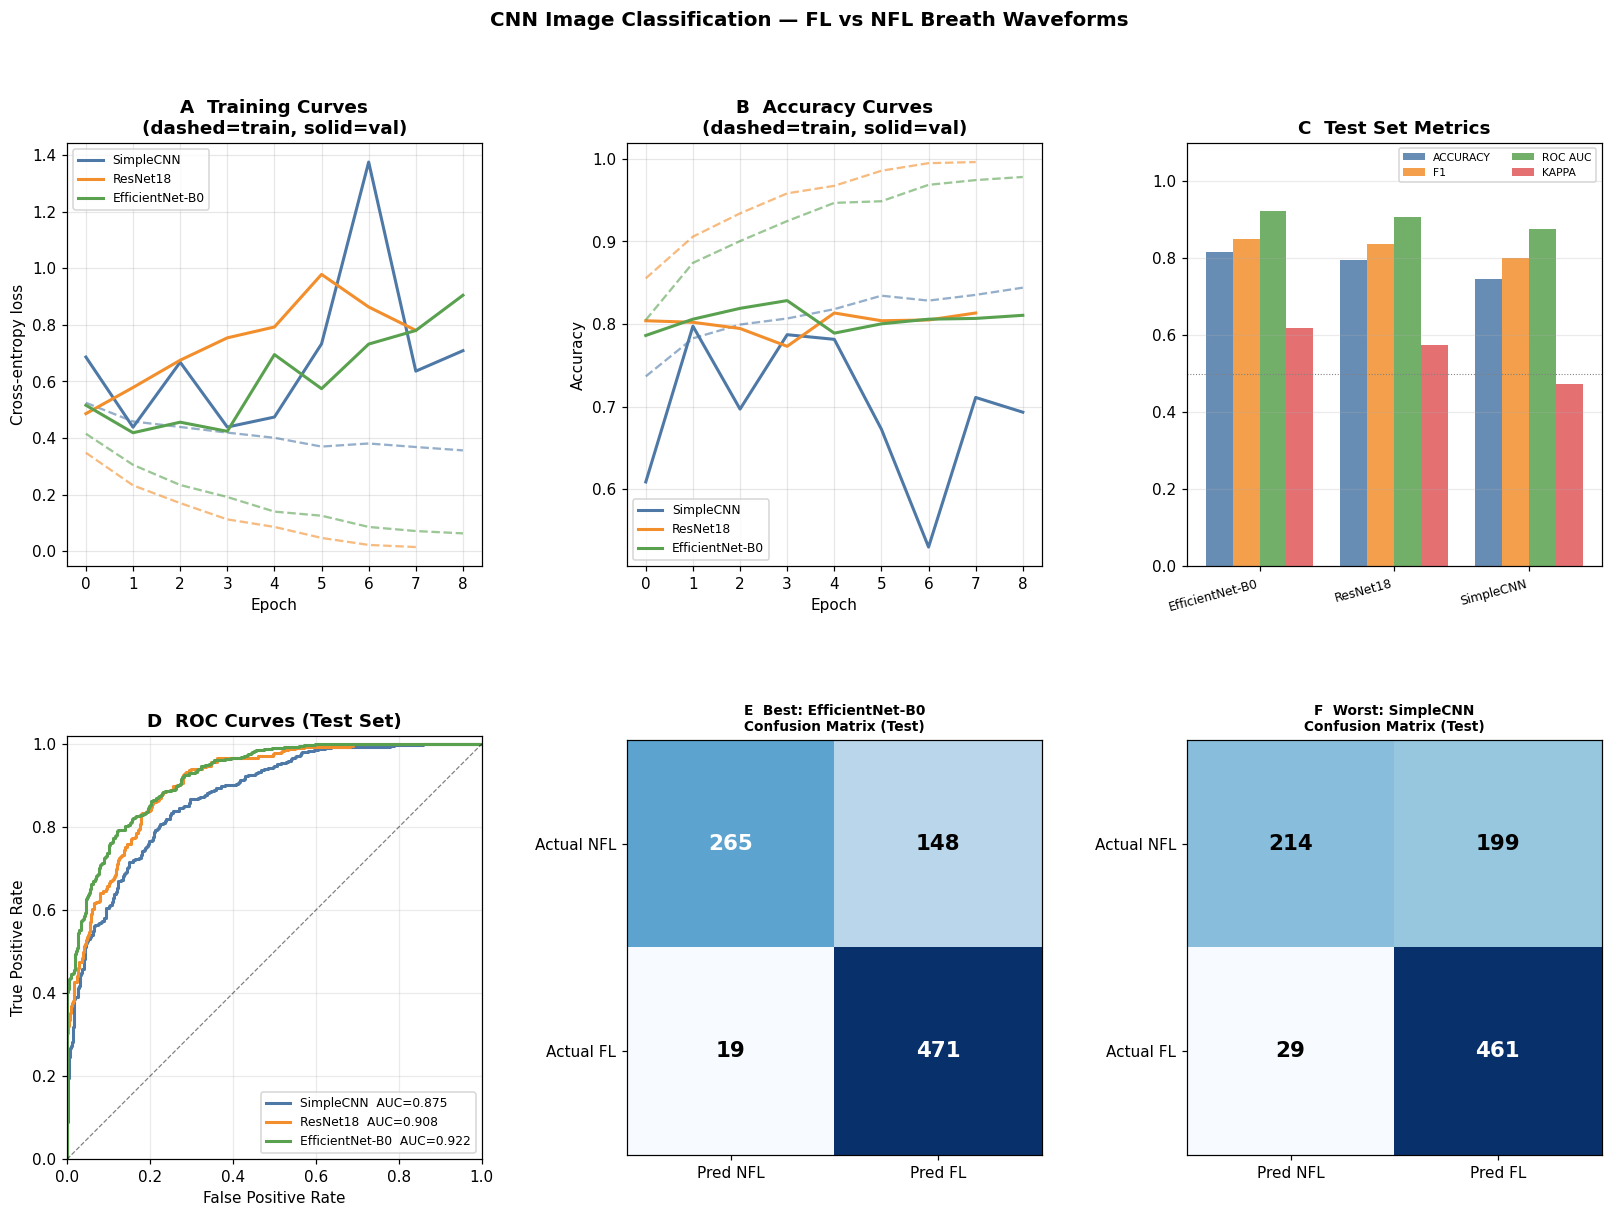

Saved: models/cnn_results.png


In [17]:
model_colors = {'SimpleCNN': '#4e79a7', 'ResNet18': '#f28e2b', 'EfficientNet-B0': '#59a14f'}

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── A: Training curves (loss) ─────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, 0])
for name, history in training_histories.items():
    col = model_colors[name]
    ax_loss.plot(history['train_loss'], color=col, lw=1.5, ls='--', alpha=0.6)
    ax_loss.plot(history['val_loss'],   color=col, lw=2.0, label=name)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Cross-entropy loss')
ax_loss.set_title('A  Training Curves\n(dashed=train, solid=val)', fontweight='bold')
ax_loss.legend(fontsize=8)
ax_loss.grid(alpha=0.3)

# ── B: Training curves (accuracy) ────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, 1])
for name, history in training_histories.items():
    col = model_colors[name]
    ax_acc.plot(history['train_acc'], color=col, lw=1.5, ls='--', alpha=0.6)
    ax_acc.plot(history['val_acc'],   color=col, lw=2.0, label=name)
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.set_title('B  Accuracy Curves\n(dashed=train, solid=val)', fontweight='bold')
ax_acc.legend(fontsize=8)
ax_acc.grid(alpha=0.3)

# ── C: Metric bars on test set ────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 2])
model_names_sorted = summary_df['model'].tolist()
x      = np.arange(len(model_names_sorted))
width  = 0.2
bar_cols = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
offsets  = np.linspace(-(len(metrics_order)-1)/2*width,
                        (len(metrics_order)-1)/2*width, len(metrics_order))
for i, m in enumerate(metrics_order):
    vals = [summary_df[summary_df['model']==n][m].values[0] for n in model_names_sorted]
    ax_bar.bar(x + offsets[i], vals, width, label=m.upper().replace('_',' '),
               color=bar_cols[i], alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(model_names_sorted, rotation=15, ha='right', fontsize=8)
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title('C  Test Set Metrics', fontweight='bold')
ax_bar.legend(fontsize=7, ncol=2)
ax_bar.axhline(0.5, color='grey', lw=0.7, ls=':')
ax_bar.grid(axis='y', alpha=0.25)

# ── D: ROC curves ─────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, 0])
for name, (metrics, trues, probas, _) in test_results.items():
    fpr, tpr, _ = roc_curve(trues, probas)
    roc_auc     = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, color=model_colors[name],
                label=f'{name}  AUC={roc_auc:.3f}')
ax_roc.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax_roc.set_xlim([0,1]); ax_roc.set_ylim([0,1.02])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('D  ROC Curves (Test Set)', fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(alpha=0.25)

# ── E & F: Confusion matrices for best and worst model ───────────────────────
best_name  = summary_df.iloc[0]['model']
worst_name = summary_df.iloc[-1]['model']

for ax_idx, name in [(gs[1, 1], best_name), (gs[1, 2], worst_name)]:
    ax_cm = fig.add_subplot(ax_idx)
    _, trues, _, preds = test_results[name]
    cm = confusion_matrix(trues, preds)
    im = ax_cm.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
    ax_cm.set_xticklabels(['Pred NFL','Pred FL'])
    ax_cm.set_yticklabels(['Actual NFL','Actual FL'])
    label_tag = 'E  Best' if name == best_name else 'F  Worst'
    ax_cm.set_title(f'{label_tag}: {name}\nConfusion Matrix (Test)', fontweight='bold', fontsize=9)

plt.suptitle('CNN Image Classification — FL vs NFL Breath Waveforms',
             fontsize=13, fontweight='bold')
plt.savefig(OUT_DIR / 'cnn_results.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: models/cnn_results.png')

## 11. Per-patient breakdown on test set

Since test patients are held out at the patient level, we can compute per-patient accuracy for the best model — directly comparable in spirit to the LOPO-CV per-patient table in notebook 02.

In [18]:
best_model = trained_models[best_name]
best_model.eval().to(DEVICE)

per_patient_rows = []

for pid in test_pids:
    pid_df  = test_df[test_df['participant'] == pid].reset_index(drop=True)
    pid_ds  = BreathDataset(pid_df, transform=eval_transform)
    pid_loader = DataLoader(pid_ds, batch_size=BATCH_SIZE, shuffle=False)

    all_t, all_p, all_s = [], [], []
    with torch.no_grad():
        for imgs, labels in pid_loader:
            imgs   = imgs.to(DEVICE)
            logits = best_model(imgs)
            probs  = torch.softmax(logits, 1)[:, 1].cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_t.extend(labels.numpy())
            all_p.extend(preds)
            all_s.extend(probs)

    t, p, s = np.array(all_t), np.array(all_p), np.array(all_s)
    try:
        roc = roc_auc_score(t, s)
    except ValueError:
        roc = np.nan

    per_patient_rows.append({
        'participant': pid,
        'n_fl'       : int(t.sum()),
        'n_nfl'      : int((t == 0).sum()),
        'accuracy'   : accuracy_score(t, p),
        'f1'         : f1_score(t, p, zero_division=0),
        'roc_auc'    : roc,
        'kappa'      : cohen_kappa_score(t, p),
    })

per_pt_df = pd.DataFrame(per_patient_rows).sort_values('roc_auc', ascending=False)
print(f'=== Per-patient test results ({best_name}) ===')
print(per_pt_df.to_string(index=False))
print(f'\nMean ROC-AUC : {per_pt_df["roc_auc"].mean():.4f} ± {per_pt_df["roc_auc"].std():.4f}')

=== Per-patient test results (EfficientNet-B0) ===
participant  n_fl  n_nfl  accuracy       f1  roc_auc    kappa
 TC_2021-07     7     14  1.000000 1.000000 1.000000 1.000000
 BB_2021-05    30     26  0.964286 0.967742 0.991026 0.927835
 TH_2023-11    97     40  0.941606 0.959184 0.987371 0.856657
 DD_2024-03    23     41  0.890625 0.837209 0.972428 0.755459
 DM_2025-01    72     75  0.891156 0.896104 0.958889 0.782825
 AL_2023-01    53     21  0.824324 0.890756 0.945193 0.468508
 MS_2022-03    30      7  0.891892 0.937500 0.938095 0.548780
 RA_2024-02    14      7  0.761905 0.838710 0.918367 0.400000
 AR_2024-02    43     26  0.739130 0.823529 0.911449 0.367617
 RV_2023-05    44     28  0.722222 0.814815 0.875812 0.328358
 JE_2024-06    62    111  0.658960 0.654971 0.809358 0.364723
 RA_2023-05    15     17  0.531250 0.666667 0.784314 0.111111

Mean ROC-AUC : 0.9244 ± 0.0698


## 12. Final Summary

In [19]:
print('=== Image Classification Summary ===')
print(f'  Dataset     : {len(img_df)} images  |  '
      f'{img_df["participant"].nunique()} patients  |  '
      f'{100*img_df["target"].mean():.1f}% FL')
print(f'  Split       : {train_df["participant"].nunique()} train / '
      f'{val_df["participant"].nunique()} val / '
      f'{test_df["participant"].nunique()} test patients')
print()
print(f'  {"Model":<20} {"Accuracy":>10} {"F1":>8} {"ROC-AUC":>10} {"Kappa":>8}')
print('  ' + '-'*58)
for _, row in summary_df.iterrows():
    print(f'  {row["model"]:<20} {row["accuracy"]:>10.4f} '
          f'{row["f1"]:>8.4f} {row["roc_auc"]:>10.4f} {row["kappa"]:>8.4f}')
print()
print(f'  Best model  : {best_name}')
print()
print('  Saved files:')
for f in ['cnn_simplecnn.pt', 'cnn_resnet18.pt', 'cnn_efficientnetb0.pt', 'cnn_results.png']:
    p = OUT_DIR / f
    print(f'    {"✓" if p.exists() else "—"}  {f}')

=== Image Classification Summary ===
  Dataset     : 7007 images  |  84 patients  |  51.9% FL
  Split       : 60 train / 12 val / 12 test patients

  Model                  Accuracy       F1    ROC-AUC    Kappa
  ----------------------------------------------------------
  EfficientNet-B0          0.8151   0.8494     0.9224   0.6180
  ResNet18                 0.7951   0.8364     0.9078   0.5750
  SimpleCNN                0.7475   0.8017     0.8750   0.4743

  Best model  : EfficientNet-B0

  Saved files:
    ✓  cnn_simplecnn.pt
    ✓  cnn_resnet18.pt
    ✓  cnn_efficientnetb0.pt
    ✓  cnn_results.png
